# Campaign property trends

Manual, read-only exploration of every `data/results/begins_*/agg.csv`. Each marker is a sample mean and each error bar is **±1 intra-sample standard deviation**. Actual raw specimen timestamps are used when available; processing timestamps are the fallback.

Run the cells from top to bottom. Edit only the settings cell for normal use.

In [63]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Works whether Jupyter starts in the repository root or EVALUATE/.
repo_root = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
evaluate_dir = repo_root / 'EVALUATE'
if str(evaluate_dir) not in sys.path:
    sys.path.insert(0, str(evaluate_dir))

from campaign_trends import (
    available_properties, export_campaign, load_campaign_data,
    plot_properties, select_campaign,
)

## Settings

In [64]:
PROPERTIES = [
    'Thickness',
    'Elastic Modulus',
    'Yield Strength',
    'Pore Fraction',
    'Creep Strain',
    'Strain at 50 bar',
]
START = None       # Example: '2026-08-10'
END = None         # Example: '2026-08-22' (the full day is included)
CAMPAIGNS = None   # Example: ['2026-08-20-exploration-mode']; None means all
CONNECT_POINTS = True
SAVE_OUTPUTS = False
CHEMISTRY_FILTER = 'Polysulfone / PolarClean (inferred)'  # Set to None for every chemistry

## Campaign interpretation

The dated `llm.csv` suggestions identify the campaign intent as follows:

- **Aug 11–20 afternoon:** directed mechanical optimization. The suggestions repeatedly state the primary objective is to maximize Elastic Modulus and the secondary objective is to minimize Strain at 50 bar. The 17 wt%, additive-free formulation is treated as Polysulfone/PolarClean.
- **From Aug 20 exploration-mode onward:** deliberate design-space exploration. The LLM suggestions explicitly prioritize sparse-region coverage, while retaining modulus/strain as downstream objectives.

These labels are campaign-level interpretations, not analytical identification of the chemicals. Change `PHASES` below if laboratory records provide more exact boundaries. Dashed lines are the running best achieved value: upper envelope for maximization and lower envelope for minimization.

In [65]:
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Boundaries inferred from the dated LLM suggestions. None means extend to plot edge.
PHASES = [
    dict(start=None, end='2026-08-20 16:30',
         label='Polysulfone / PolarClean\nmaximize modulus; minimize strain', color='#7fc8a9'),
    dict(start='2026-08-20 16:30', end=None,
         label='Polysulfone / PolarClean\nexplorative design-space coverage', color='#91b7e8'),
]

# Direction is based on the objectives stated in the LLM suggestions. Add/edit as needed.
GOAL_DIRECTION = {
    'Elastic Modulus': 'maximize',
    'Yield Strength': 'maximize',
    'Strain at 50 bar': 'minimize',
    'Strain at 80 bar': 'minimize',
    'Strain at 150 bar': 'minimize',
    'Strain at 500 bar': 'minimize',
}

def infer_chemistry(row):
    """Notebook-only heuristic supplied with the campaign context."""
    polymer = pd.to_numeric(row.get('polymer_wt'), errors='coerce')
    additive = pd.to_numeric(row.get('additive_wt'), errors='coerce')
    name = str(row.get('condition', ''))
    if (pd.notna(polymer) and polymer >= 20 and pd.notna(additive) and additive > 0) or (name.startswith('21-') and not name.startswith('21-0add')):
        return 'Primospire / NMP + PVP (inferred)'
    if (pd.notna(polymer) and polymer >= 20) or name.startswith('21-'):
        return 'Primospire / NMP, no PVP (inferred)'
    if pd.notna(polymer) and polymer <= 17:
        return 'Polysulfone / PolarClean (inferred)'
    return 'Unclassified formulation'

def _shade_phases(ax, points):
    for phase in PHASES:
        mask = pd.Series(True, index=points.index)
        if phase['start'] is not None:
            mask &= points['sample_time'] >= pd.Timestamp(phase['start'])
        if phase['end'] is not None:
            mask &= points['sample_time'] < pd.Timestamp(phase['end'])
        phase_iterations = points.loc[mask, 'iteration']
        if not phase_iterations.empty:
            ax.axvspan(phase_iterations.min() - 0.5, phase_iterations.max() + 0.5,
                       color=phase['color'], alpha=0.18, zorder=0)

def plot_detailed_campaign(data, properties, color_column, color_label, *,
                           nitrogen_markers=False, columns=2, connect_points=True, cmap='viridis'):
    """Plot one campaign view with a selectable color variable and fixed marker size."""
    import math
    properties = list(properties)
    columns = max(1, min(columns, len(properties)))
    rows = math.ceil(len(properties) / columns)
    fig, grid = plt.subplots(rows, columns, figsize=(8.5 * columns, 5.2 * rows), squeeze=False)
    axes = list(grid.flat)
    valid_times = data['sample_time'].dropna()
    minimum_time, maximum_time = valid_times.min(), valid_times.max()
    enriched = data.copy()
    enriched['chemistry'] = enriched.apply(infer_chemistry, axis=1)
    enriched = enriched.sort_values('sample_time').reset_index(drop=True)
    enriched['iteration'] = enriched.index + 1
    color_values = pd.to_numeric(enriched[color_column], errors='coerce')
    color_min, color_max = color_values.min(), color_values.max()
    if color_min == color_max:
        color_min -= 0.5
        color_max += 0.5
    normalization = plt.Normalize(color_min, color_max)
    color_map = plt.get_cmap(cmap)
    def nitrogen_is_on(value):
        return value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}
    for ax, prop in zip(axes, properties):
        mean_col, sd_col = f'{prop} Mean', f'{prop} SD'
        points = enriched.dropna(subset=['sample_time', mean_col]).sort_values('sample_time')
        _shade_phases(ax, enriched)
        if connect_points:
            ax.plot(points['iteration'], points[mean_col], color='#707070', lw=0.9, alpha=0.55, zorder=2)
        point_color_values = pd.to_numeric(points[color_column], errors='coerce').fillna(color_values.median())
        point_colors = color_map(normalization(point_color_values))
        for (_, point), color in zip(points.iterrows(), point_colors):
            error = pd.to_numeric(pd.Series([point.get(sd_col)]), errors='coerce').fillna(0).iloc[0]
            marker = ('o' if nitrogen_is_on(point.get('nitrogen')) else 's') if nitrogen_markers else 'o'
            ax.errorbar(point['iteration'], point[mean_col], yerr=error,
                        fmt=marker, linestyle='none', color=color, ecolor=color,
                        markeredgecolor='black', markeredgewidth=1.2,
                        markersize=11, capsize=4, elinewidth=1.3, zorder=3)
        direction = GOAL_DIRECTION.get(prop)
        if direction:
            values = pd.to_numeric(points[mean_col], errors='coerce')
            running_best = values.cummax() if direction == 'maximize' else values.cummin()
            ax.step(points['iteration'], running_best, where='post', color='#b21f35',
                    linestyle='--', linewidth=1.6,
                    label=f'Running best ({direction})', zorder=4)
        ax.set_title(prop, fontsize=20, fontweight='semibold', pad=12)
        ax.set_xlabel('Iteration (chronological order)', fontsize=16, labelpad=9)
        ax.set_ylabel(f'{prop} (mean ± SD)', fontsize=13, labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.label.set_size(16)
        ax.grid(True, alpha=0.22)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xlim(0.5, len(enriched) + 0.5)
    for ax in axes[len(properties):]:
        ax.remove()
    phase_handles = [Patch(facecolor=p['color'], alpha=.25, label=p['label']) for p in PHASES]
    goal_handle = plt.Line2D([], [], color='#b21f35', linestyle='--', label='Optimization goal: running best')
    nitrogen_handles = [
        plt.Line2D([], [], marker='o', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen on'),
        plt.Line2D([], [], marker='s', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen off'),
    ]
    legend_handles = phase_handles + [goal_handle] + (nitrogen_handles if nitrogen_markers else [])
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.12),
               ncol=4, frameon=False, fontsize=13, labelspacing=1.0, columnspacing=1.5)
    color_scale = plt.cm.ScalarMappable(norm=normalization, cmap=color_map)
    color_scale.set_array([])
    # A dedicated axis keeps the color scale clear of the right-hand plots.
    fig.subplots_adjust(left=0.09, right=0.87, bottom=0.25, top=0.90, wspace=0.32, hspace=0.42)
    colorbar_axis = fig.add_axes([0.915, 0.25, 0.018, 0.55])
    colorbar = fig.colorbar(color_scale, cax=colorbar_axis)
    colorbar.set_label(color_label, fontsize=16, labelpad=14)
    colorbar.ax.tick_params(labelsize=14)
    fig.suptitle(f'Polysulfone / PolarClean properties — color: {color_label}',
                 fontsize=22, fontweight='semibold')
    return fig, axes[:len(properties)], enriched

In [66]:
all_data = load_campaign_data(repo_root / 'data' / 'results', repo_root / 'data' / 'raw')
campaign = select_campaign(all_data, start=START, end=END, campaigns=CAMPAIGNS)
campaign['chemistry'] = campaign.apply(infer_chemistry, axis=1)
if CHEMISTRY_FILTER is not None:
    campaign = campaign[campaign['chemistry'] == CHEMISTRY_FILTER].copy()
property_mean_columns = [f'{prop} Mean' for prop in PROPERTIES]
campaign = campaign[campaign[property_mean_columns].notna().any(axis=1)].copy()
campaign = campaign[pd.to_numeric(campaign['Thickness Mean'], errors='coerce') >= 70].copy()
# Remove the incomplete 10 wt% baseline; the retained PolarClean campaign spans 13–17 wt%.
campaign = campaign[pd.to_numeric(campaign['polymer_wt'], errors='coerce') >= 13].copy()
print(f'{len(campaign)} samples from {campaign.sample_time.min()} to {campaign.sample_time.max()}')
print('Available properties:', available_properties(campaign))
campaign[['sample_time', 'condition', 'campaign', 'chemistry', 'time_source']].head()

31 samples from 2026-08-14 19:51:41 to 2026-08-23 04:29:21
Available properties: ['Creep Strain', 'Elastic Modulus', 'Pore Fraction', 'Slope Densification', 'Slope Plateau', 'Strain at 150 bar', 'Strain at 50 bar', 'Strain at 500 bar', 'Strain at 80 bar', 'Thickness', 'Yield Strength']


,sample_time,condition,campaign,chemistry,time_source
14,2026-08-14 19:51:41,17-0add-5deg-30s-N2-125s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
15,2026-08-14 20:39:10,17-0add-5deg-60s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
16,2026-08-14 21:55:19,17-0add-5deg-90s-N2-1800s_run2,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
17,2026-08-14 23:14:19,17-0add-5deg-120s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
18,2026-08-15 00:32:14,17-0add-5deg-90s-N2-1800s_run3,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename


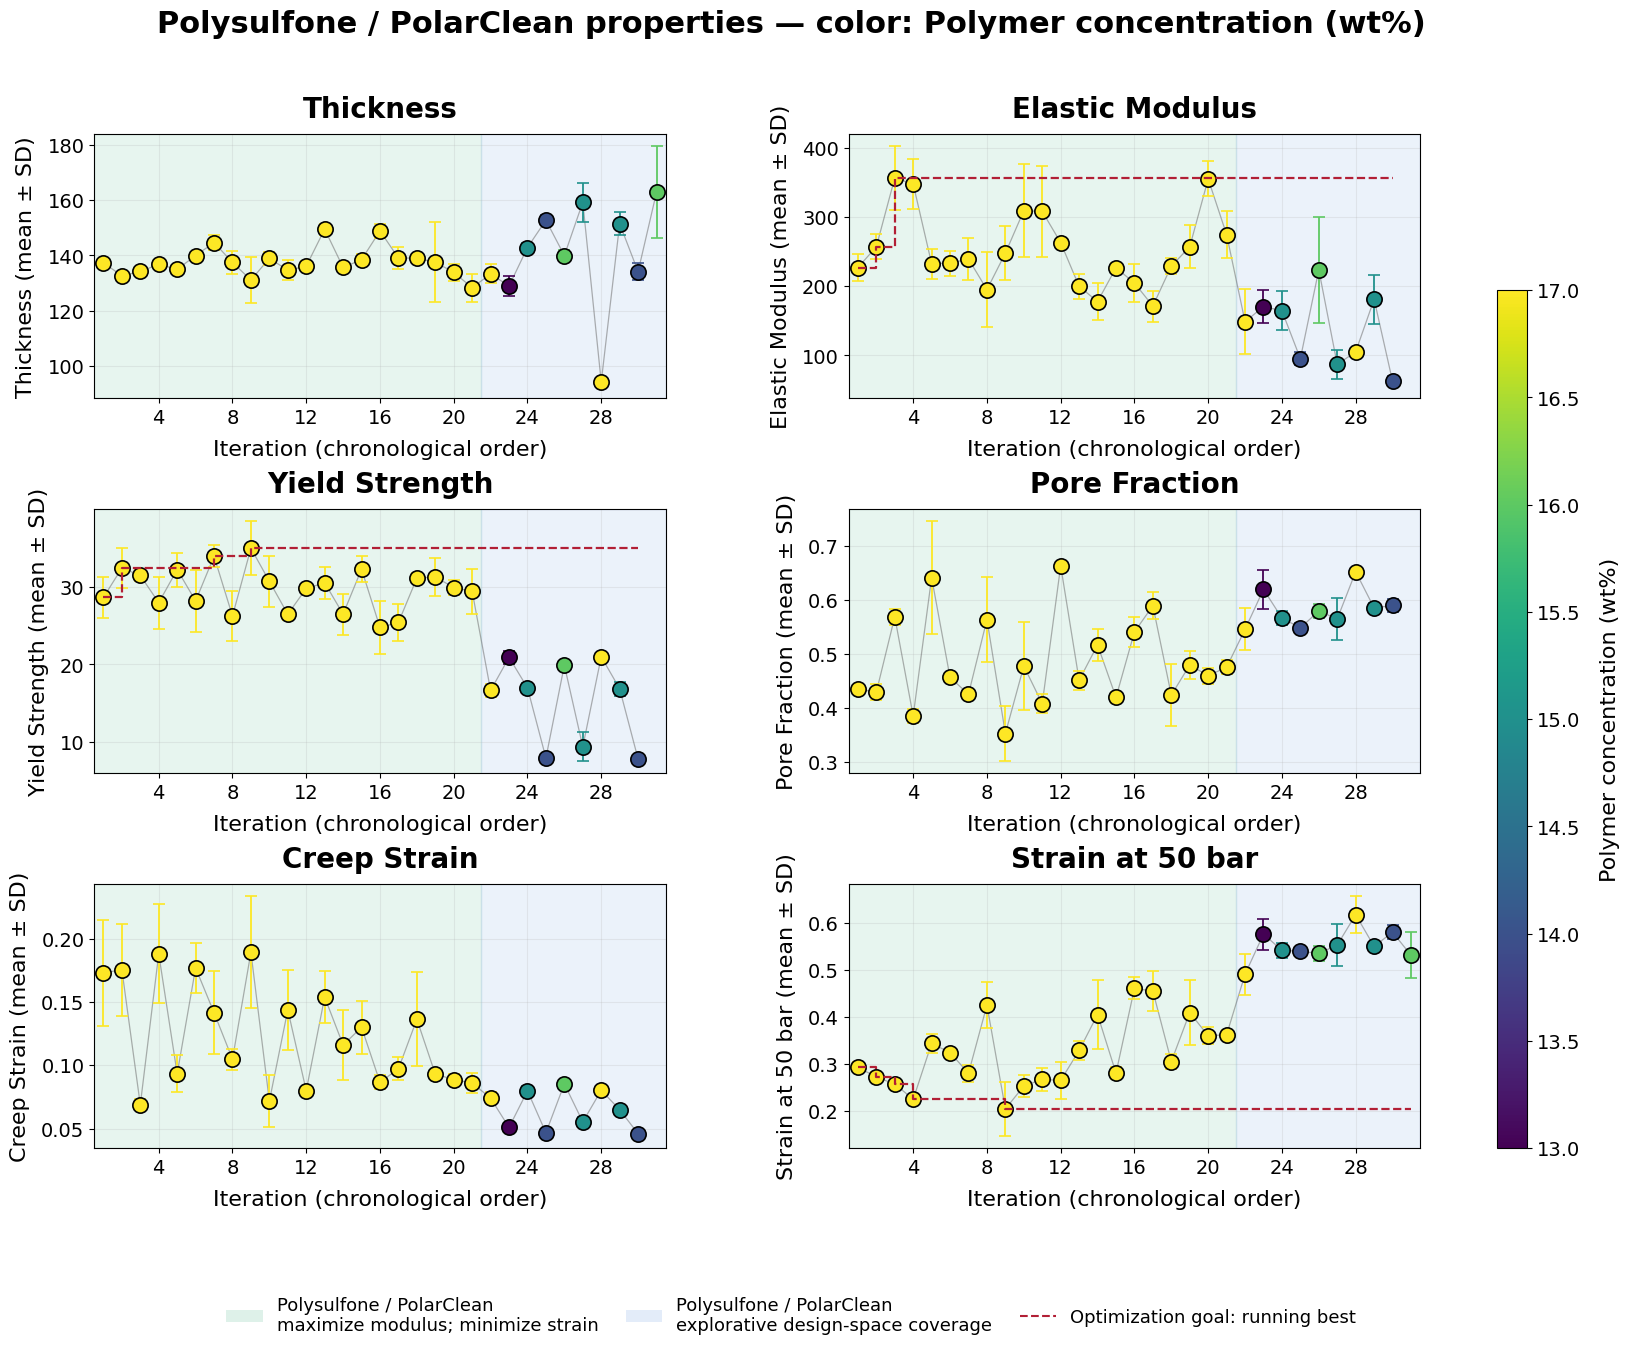

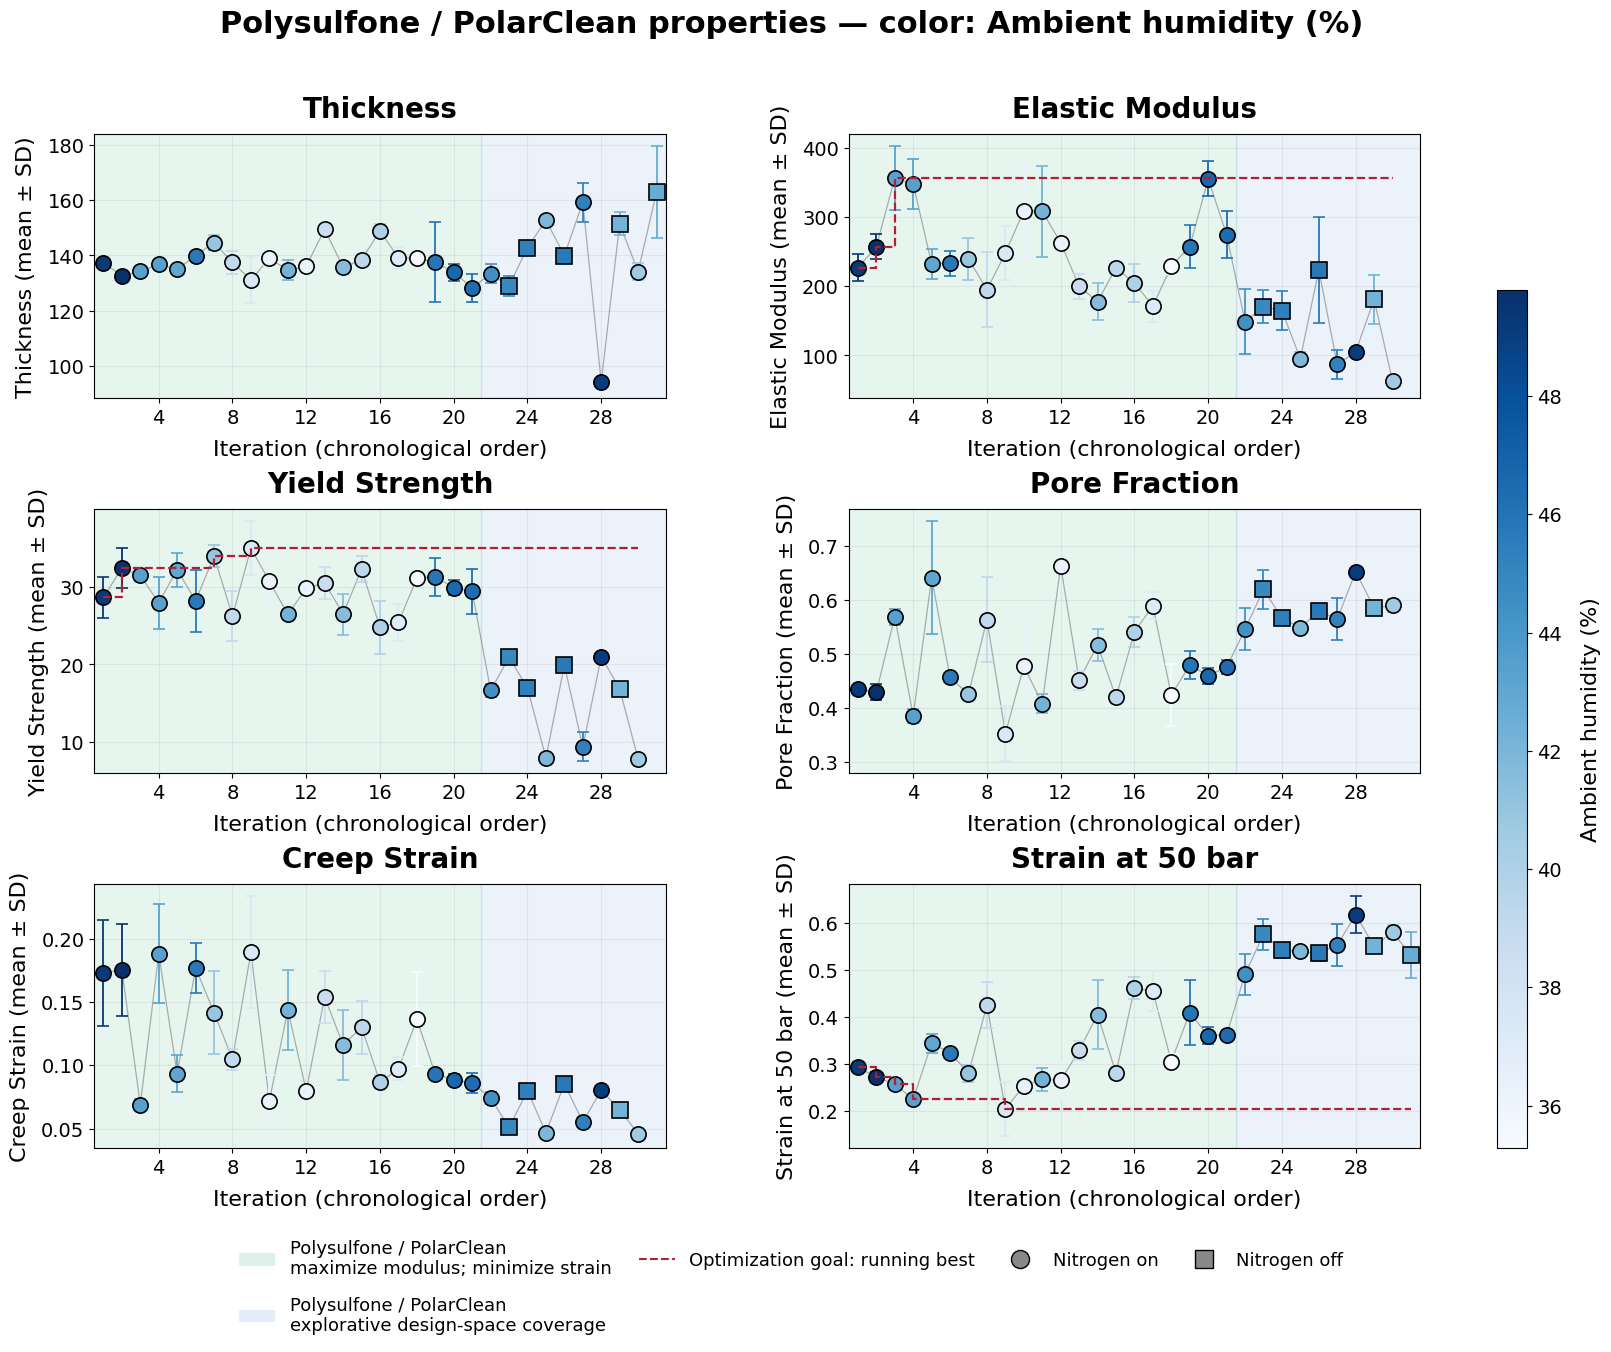

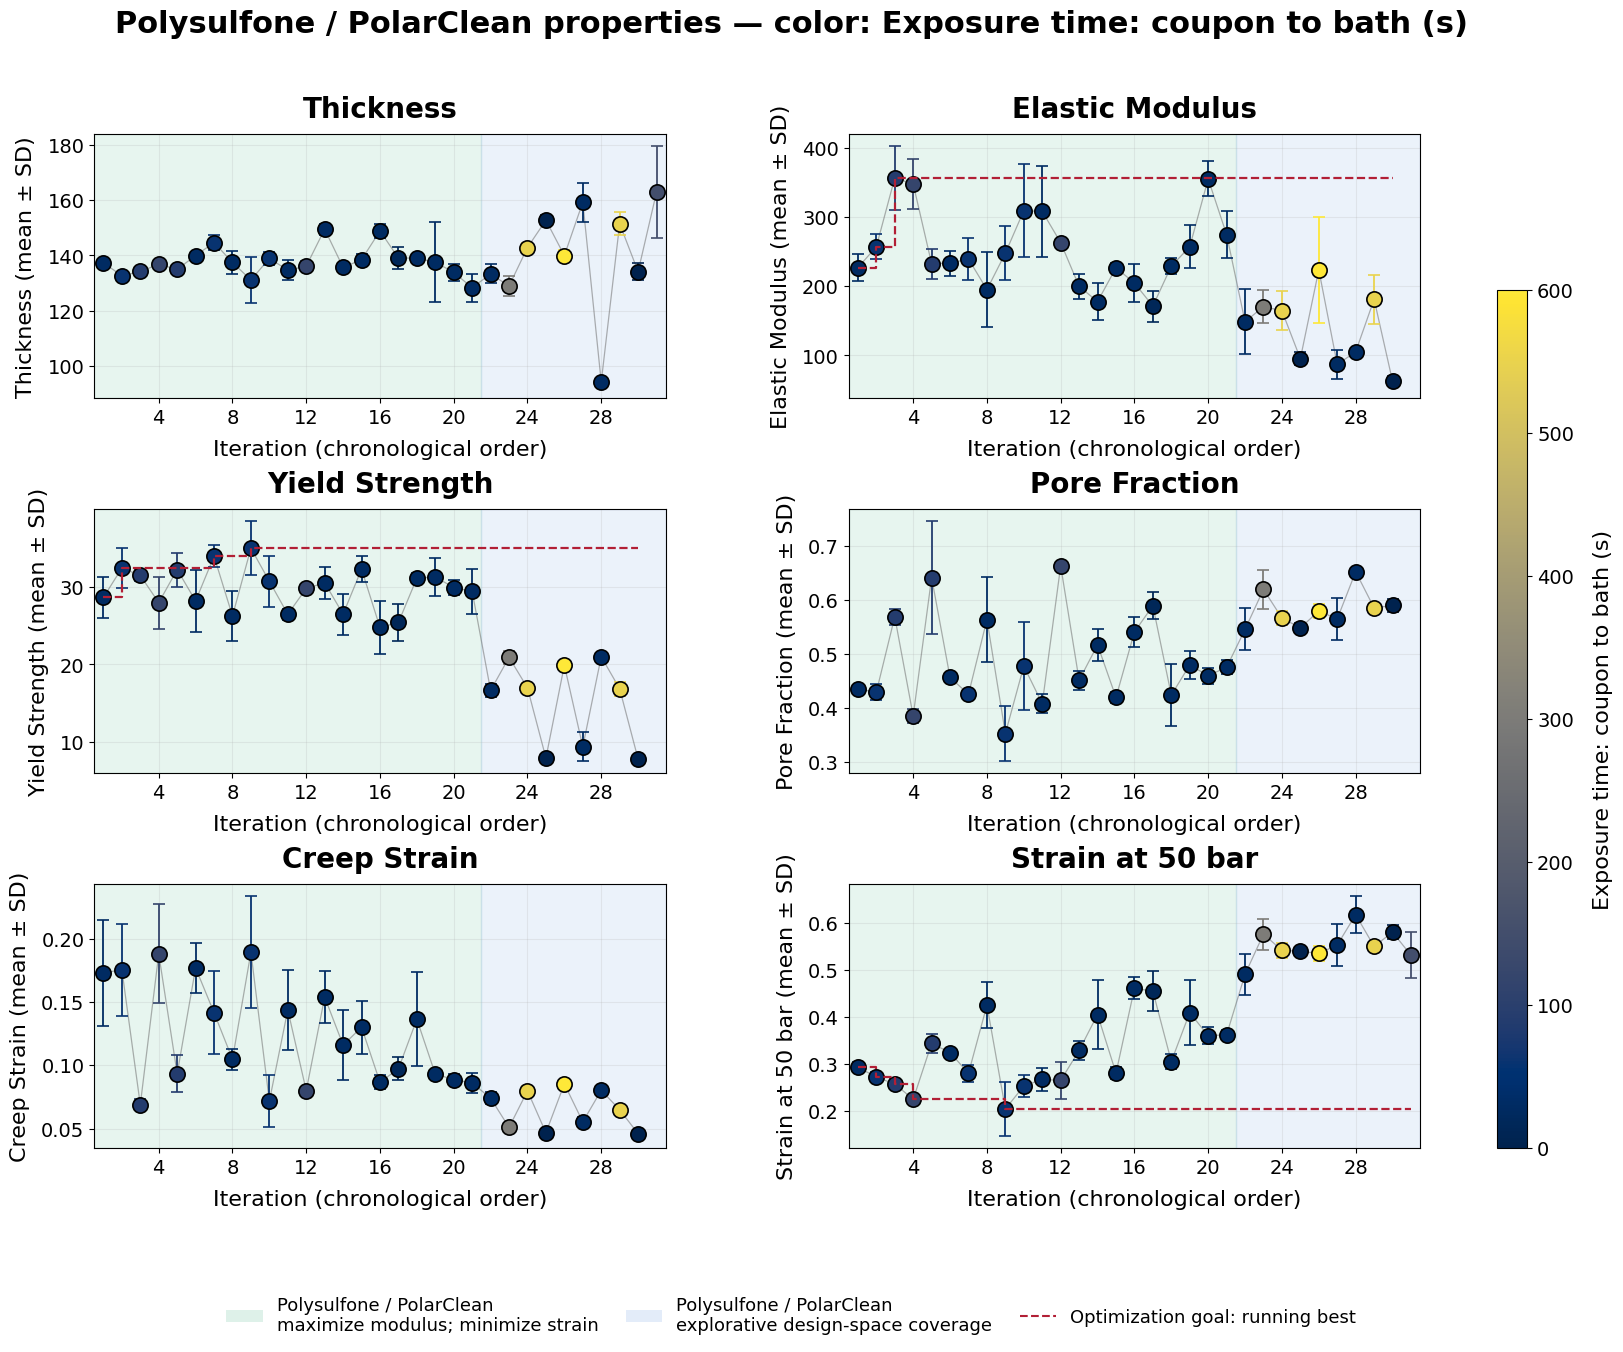

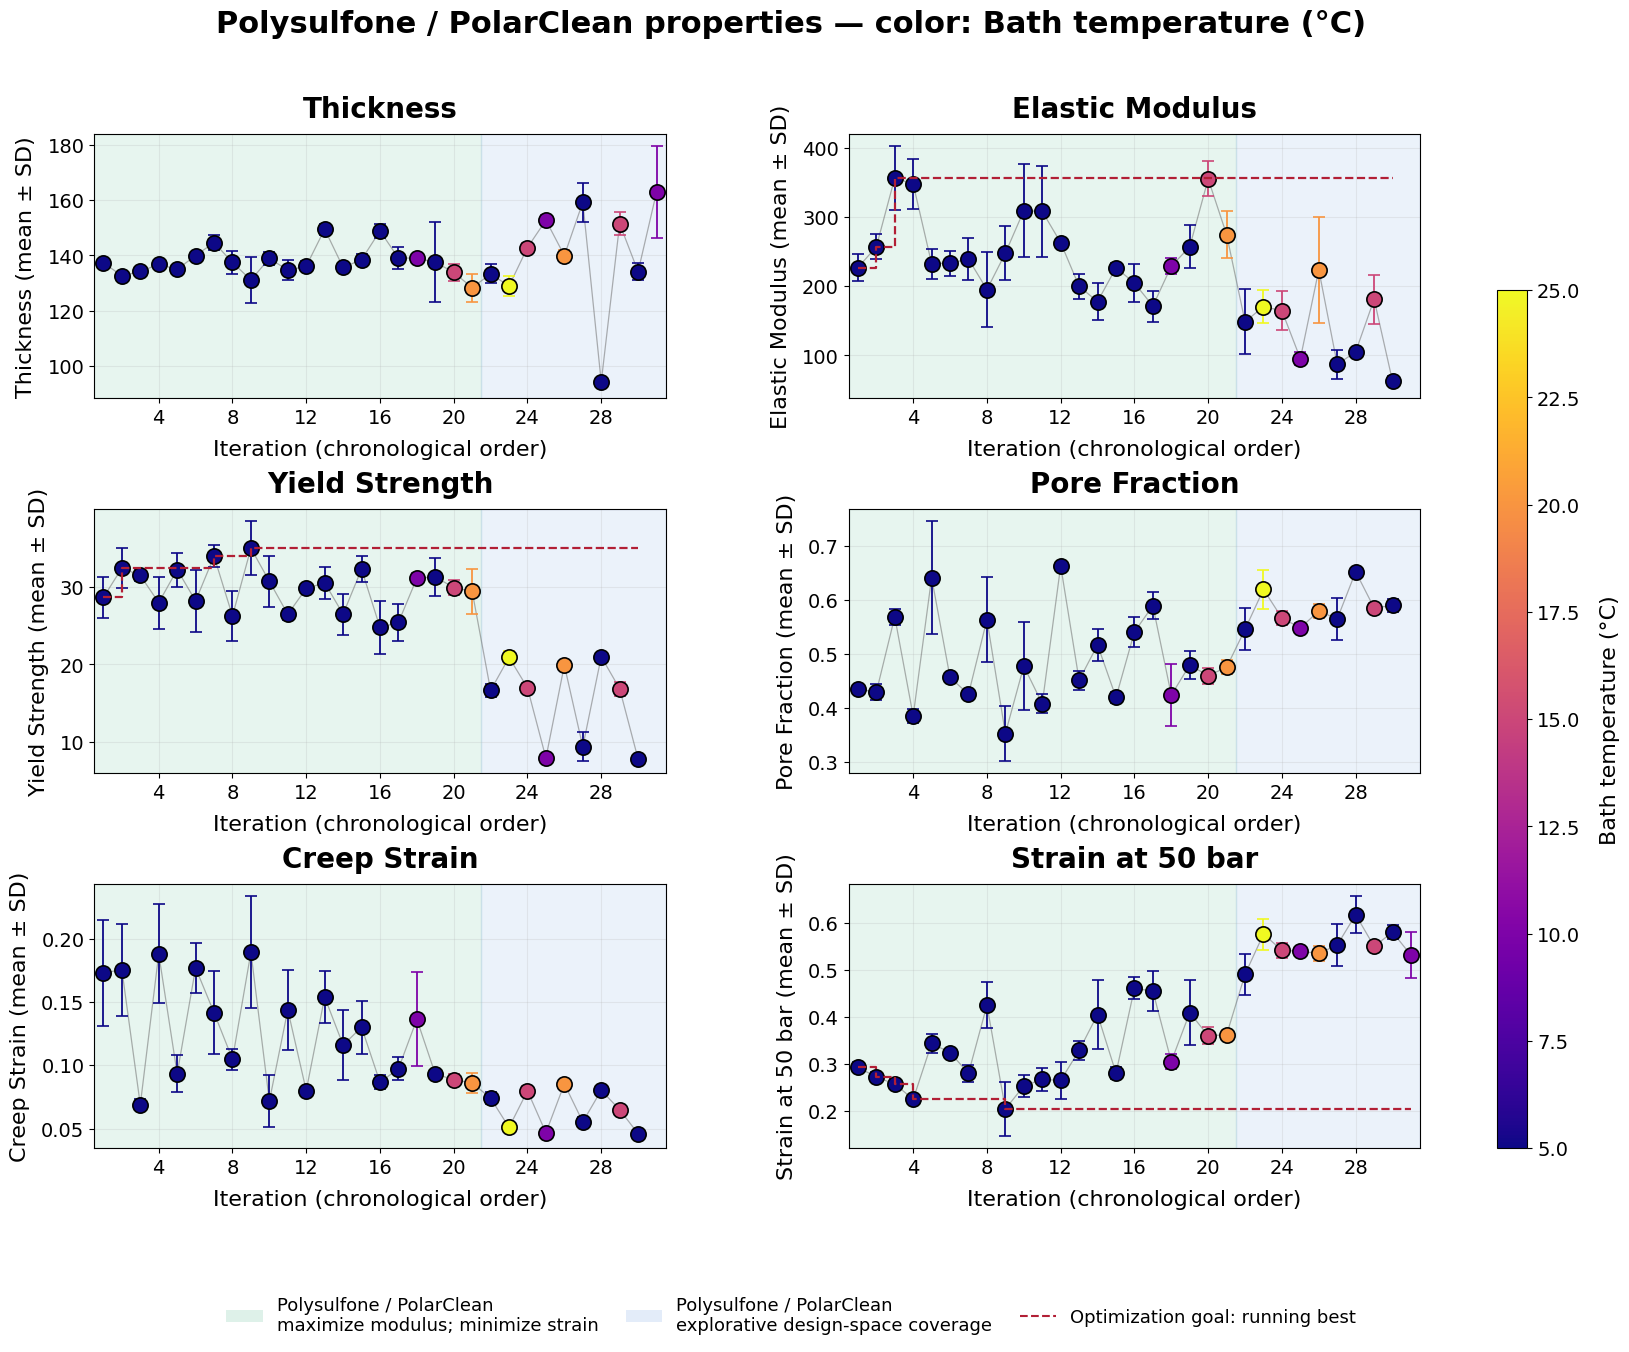

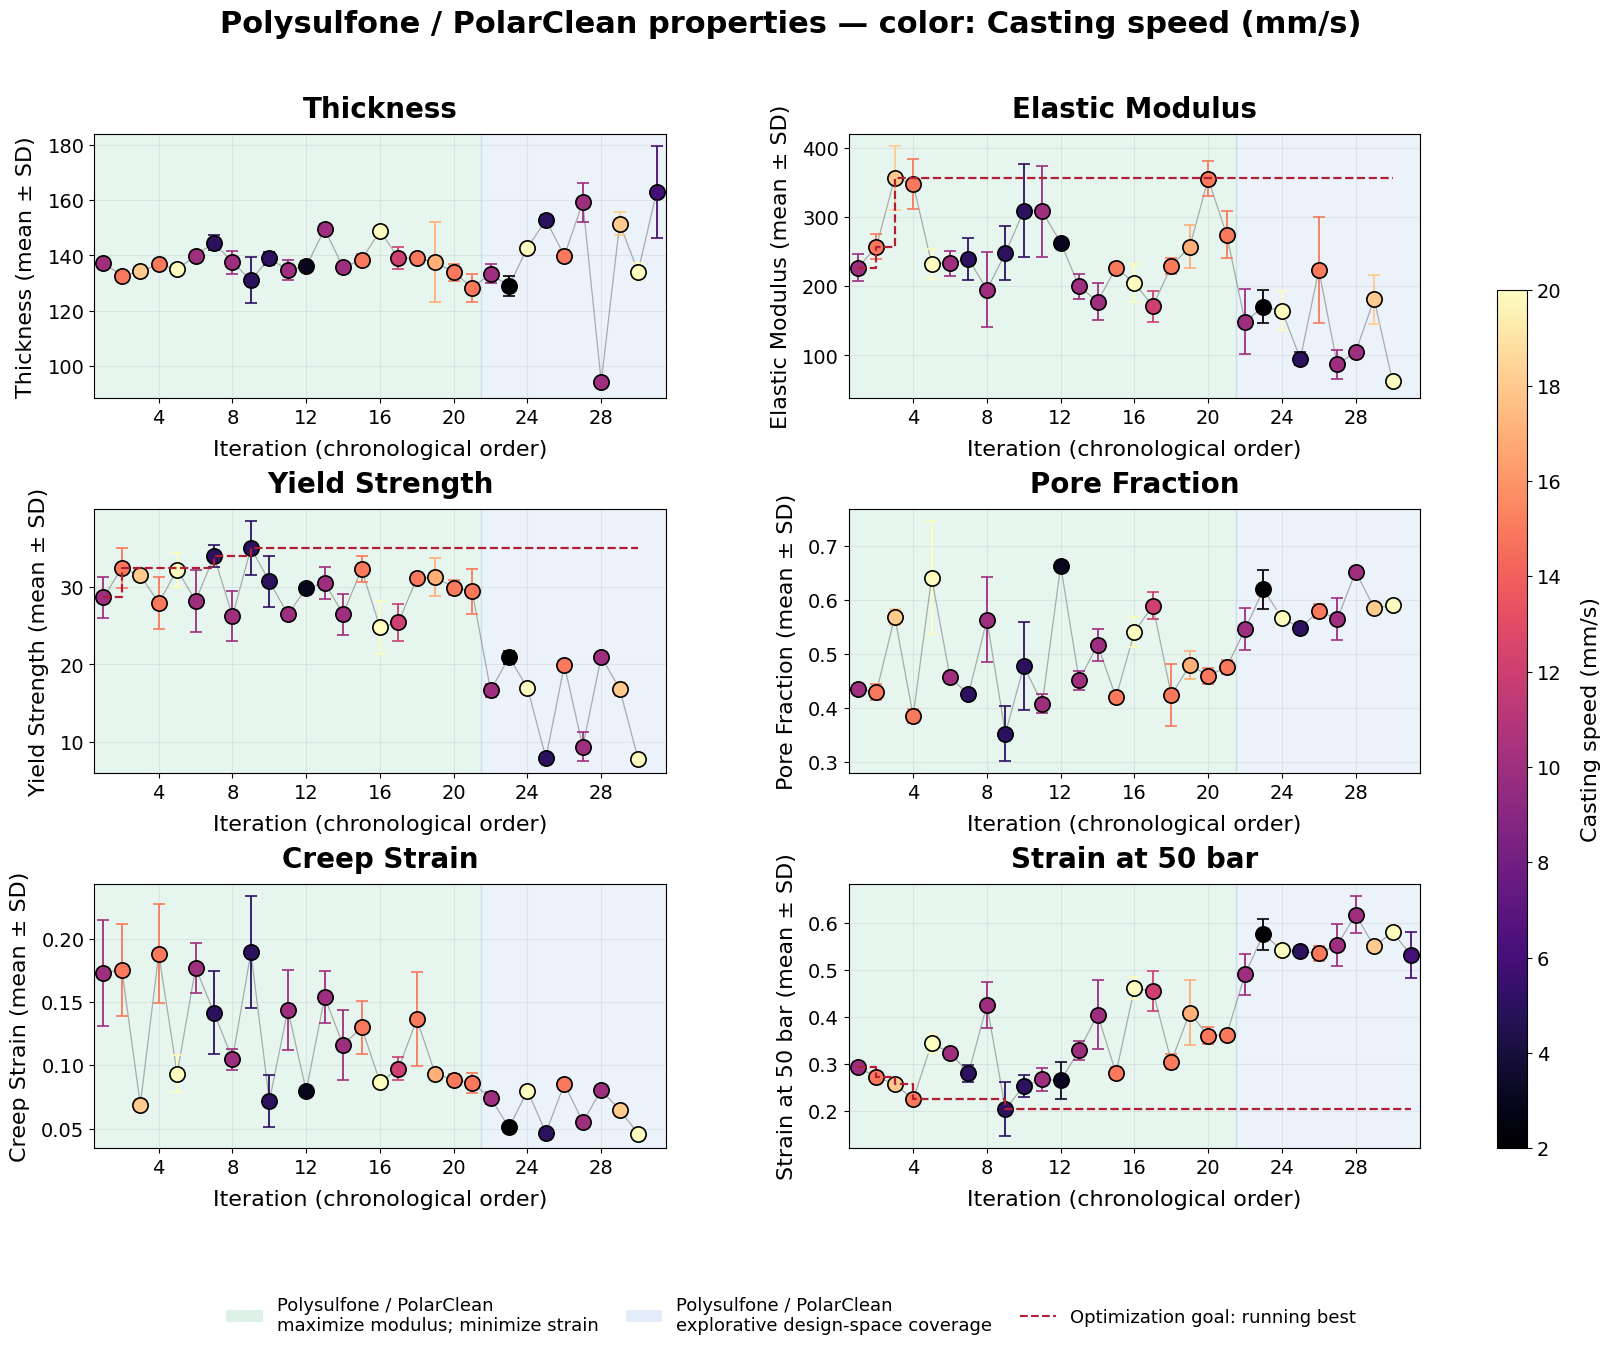

In [67]:
figure_polymer, axes_polymer, campaign_detailed = plot_detailed_campaign(
    campaign, PROPERTIES, 'polymer_wt', 'Polymer concentration (wt%)',
    connect_points=CONNECT_POINTS, cmap='viridis'
)
figure_humidity, axes_humidity, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'Humidity Mean', 'Ambient humidity (%)',
    nitrogen_markers=True, connect_points=CONNECT_POINTS, cmap='Blues'
)
figure_exposure, axes_exposure, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'coupon_to_bath_wait_time', 'Exposure time: coupon to bath (s)',
    connect_points=CONNECT_POINTS, cmap='cividis'
)
figure_bath, axes_bath, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'bath_temp', 'Bath temperature (°C)',
    connect_points=CONNECT_POINTS, cmap='plasma'
)
figure_casting, axes_casting, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'pullcast_speed', 'Casting speed (mm/s)',
    connect_points=CONNECT_POINTS, cmap='magma'
)
plt.show()

In [68]:
# Optional explicit export of the enhanced figure/data; nothing is written otherwise.
if SAVE_OUTPUTS:
    output_dir = repo_root / 'EVALUATE' / 'campaign_trends_output'
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / 'campaign_data_detailed.csv'
    polymer_png = output_dir / 'campaign_properties_by_polymer.png'
    humidity_png = output_dir / 'campaign_properties_by_humidity_nitrogen.png'
    exposure_png = output_dir / 'campaign_properties_by_exposure_time.png'
    bath_png = output_dir / 'campaign_properties_by_bath_temperature.png'
    casting_png = output_dir / 'campaign_properties_by_casting_speed.png'
    campaign_detailed.to_csv(csv_path, index=False)
    figure_polymer.savefig(polymer_png, dpi=180, bbox_inches='tight')
    figure_humidity.savefig(humidity_png, dpi=180, bbox_inches='tight')
    figure_exposure.savefig(exposure_png, dpi=180, bbox_inches='tight')
    figure_bath.savefig(bath_png, dpi=180, bbox_inches='tight')
    figure_casting.savefig(casting_png, dpi=180, bbox_inches='tight')
    print(f'Saved {csv_path}\nSaved {polymer_png}\nSaved {humidity_png}\nSaved {exposure_png}\nSaved {bath_png}\nSaved {casting_png}')